# Delivery Performance and Customer Satisfaction

**Yash Arabhavi** | Data Visualization Design Project

**Dataset:** Brazilian e-commerce marketplace, ~100k orders, Sept 2016 to Aug 2018.

**My two questions:**

1. **How does delivery delay affect customer review scores?**
2. **Is it being slow, or breaking the promise, that angers customers?**

Run this top to bottom. It writes the charts into `figures/` and every table
behind them into `outputs/`.

## 1. Imports and setup

Colours are set once here so every chart in the notebook matches. Two colours
only, and each one means something: blue is the normal group, red is always the
bad outcome. Red never gets reused for anything else, so once you have seen one
chart you know what red means in the next.

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

FIG_DIR = Path("figures")
OUT_DIR = Path("outputs")
FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)

# Colours and furniture
SURFACE, INK, INK_SOFT = "#fcfcfb", "#0b0b0b", "#52514e"
GRID, MUTED = "#e3e2de", "#b9b8b2"
BLUE = "#2a78d6"   # the normal group
BAD  = "#e34948"   # reserved: bad outcome, never used for anything else

plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE,
    "savefig.facecolor": SURFACE, "font.family": "DejaVu Sans",
    "font.size": 10, "text.color": INK, "axes.labelcolor": INK_SOFT,
    "axes.edgecolor": GRID, "axes.titlesize": 12.5, "axes.titleweight": "bold",
    "axes.titlelocation": "left", "axes.titlepad": 14, "axes.labelsize": 9.5,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "grid.color": GRID, "grid.linewidth": 0.8, "legend.frameon": False,
    "legend.fontsize": 9, "lines.linewidth": 2.0, "figure.dpi": 110,
})

SOURCE = "Olist Brazilian E-Commerce, 2016-2018"


def finish(ax, title, subtitle="", xlabel="", ylabel="", grid_axis="y"):
    ax.set_title(title, color=INK, pad=30 if subtitle else 14)
    if subtitle:
        ax.text(0, 1.012, subtitle, transform=ax.transAxes, fontsize=9.5,
                color=INK_SOFT, va="bottom")
    if xlabel:
        ax.set_xlabel(xlabel)
    if ylabel:
        ax.set_ylabel(ylabel)
    ax.grid(axis=grid_axis, linewidth=0.8, alpha=0.9)
    ax.set_axisbelow(True)
    ax.figure.text(0.005, -0.09, SOURCE, fontsize=7.5, color=MUTED, ha="left")


def save_fig(fig, name):
    fig.savefig(FIG_DIR / name, bbox_inches="tight", pad_inches=0.28)


def save_table(df, name):
    df.to_csv(OUT_DIR / name, index=False)
    return df

print("ready")

ready


## 2. Load data

Our cleaned table is `master_orders.csv`, built by `preprocess.py` at the repo
root. One row per order, with the delivery dates, the review score and the
customer and seller details already joined.

In [2]:
# Look in the usual places so this runs whether the notebook is opened from its
# own folder or from the repo root.
CANDIDATES = [
    Path("../../processed_data/master_orders.csv"),
    Path("processed_data/master_orders.csv"),
    Path("../processed_data/master_orders.csv"),
]
MASTER = next((p for p in CANDIDATES if p.exists()), None)
if MASTER is None:
    raise FileNotFoundError(
        "master_orders.csv not found. Run `python preprocess.py` from the repo root."
    )

master = pd.read_csv(MASTER, low_memory=False)
print(f"master_orders  {len(master):>7,} rows  {master.shape[1]:>3} cols")
print()
print("columns:", list(master.columns))

master_orders   99,441 rows   45 cols

columns: ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'delay_days', 'delivery_days', 'handling_days', 'transit_days', 'promise_buffer_days', 'is_late', 'flag_approved_after_carrier', 'flag_delivered_before_carrier', 'review_score', 'is_negative', 'review_creation_date', 'n_items', 'n_sellers', 'total_price', 'total_freight', 'primary_seller_id', 'all_seller_ids', 'n_distinct_categories', 'primary_category', 'freight_ratio', 'is_multi_seller', 'n_payment_methods', 'dominant_payment_type', 'max_installments', 'total_payment_value', 'customer_unique_id', 'customer_state', 'customer_city', 'customer_lat', 'customer_lng', 'seller_state', 'seller_city', 'seller_lat', 'seller_lng', 'delay_bucket', 'geo_distance', 'is_interstate']


## 3. Data quality check

One cleaning choice could have changed my answers. When an order has more than
one review, `preprocess.py` keeps the higher score. That is a guess about how
customers behave, not something the data says, so I tried all four options.

In [3]:
RAW_CANDIDATES = [
    Path("../../Dataset/E-Commerce Dataset "),
    Path("../../Dataset/E-Commerce Dataset"),
    Path("Dataset/E-Commerce Dataset "),
]
RAW = next((p for p in RAW_CANDIDATES if p.is_dir()), None)

r = pd.read_csv(RAW / "order_reviews_dataset.csv", low_memory=False)
r["review_creation_date"] = pd.to_datetime(r["review_creation_date"], errors="coerce")

rules = {
    "keep highest score (current pipeline)":
        r.sort_values("review_score", ascending=False).drop_duplicates("order_id"),
    "keep lowest score":
        r.sort_values("review_score").drop_duplicates("order_id"),
    "keep latest review":
        r.sort_values("review_creation_date").drop_duplicates("order_id", keep="last"),
    "keep earliest review":
        r.sort_values("review_creation_date").drop_duplicates("order_id"),
}
dedup = pd.DataFrame([
    {"rule": k, "orders": len(v),
     "neg_pct": round(100 * (v["review_score"] <= 2).mean(), 3),
     "mean_score": round(v["review_score"].mean(), 4)}
    for k, v in rules.items()
])

conflicting = (r[r["order_id"].duplicated(keep=False)]
               .groupby("order_id")["review_score"].nunique() > 1).sum()
print(f"{r['order_id'].nunique():,} reviewed orders, "
      f"{conflicting} of them with two different scores")
print(f"spread across the four options: "
      f"{dedup['neg_pct'].max() - dedup['neg_pct'].min():.3f} pp")
save_table(dedup, "dq_dedup_rules.csv")

98,673 reviewed orders, 202 of them with two different scores
spread across the four options: 0.097 pp


,rule,orders,neg_pct,mean_score
0,keep highest score (current pipeline),98673,14.631,4.0889
1,keep lowest score,98673,14.728,4.0847
2,keep latest review,98673,14.690,4.0863
3,keep earliest review,98673,14.670,4.0873


The four options land within 0.1 pp of each other, so it makes no difference
which one is used and I left the pipeline alone.

## 4. Build the table for my questions

Both questions need a delay, and an order that never showed up does not have one,
so I keep delivered orders that have a review.

Two things to say up front:

- **Scope.** Keeping only delivered orders leaves some very unhappy customers
  out. That is not a neutral loss and Figure 2 is about it.
- **Metric.** I use the negative rate (share giving 1 or 2 stars), not the average
  score. The scores are lopsided: 1-star on its own is bigger than 2-star and
  3-star put together, so an average of 4.09 does not describe many people.

In [4]:
keep = (
    (master["order_status"] == "delivered")
    & master["review_score"].notna()
    & master["delay_days"].notna()
)
d = master.loc[keep].copy()

# is_negative arrives as object dtype, not bool, because preprocess.py left-joins
# the reviews onto orders and the unreviewed ones make the column True/False/NaN.
# Object booleans still sum and average by accident, which works until it does
# not, so cast it and check rather than assume.
assert d["is_negative"].notna().all()
d["is_negative"] = d["is_negative"].astype(bool)
assert (d["is_negative"] == (d["review_score"] <= 2)).all()

print(f"delivered and reviewed : {len(d):,} orders")
print(f"negative reviews       : {100 * d['is_negative'].mean():.2f}%")

delivered and reviewed : 95,824 orders
negative reviews       : 12.76%


### Two helpers

Every rate in this notebook goes through `rate_table`, so no chart can show a
percentage without also knowing how many orders it rests on.

The error bars are Wilson intervals. Some buckets here are small, and the formula
you normally see returns bounds below 0% at that size, which would look silly on
a chart of percentages.

In [5]:
Z95 = 1.959964   # 95% two-sided


def wilson(successes, n, z=Z95):
    successes = np.asarray(successes, dtype=float)
    n = np.asarray(n, dtype=float)
    with np.errstate(invalid="ignore", divide="ignore"):
        p = successes / n
        denom = 1 + z ** 2 / n
        centre = (p + z ** 2 / (2 * n)) / denom
        half = (z / denom) * np.sqrt(p * (1 - p) / n + z ** 2 / (4 * n ** 2))
    return 100 * (centre - half), 100 * (centre + half)


def rate_table(df, by, observed=True):
    g = df.groupby(by, observed=observed).agg(
        n=("order_id", "size"),
        n_negative=("is_negative", "sum"),
        mean_score=("review_score", "mean"),
    )
    g["neg_pct"] = 100 * g["n_negative"] / g["n"]
    g["ci_lo"], g["ci_hi"] = wilson(g["n_negative"], g["n"])
    return g.reset_index()

print("helpers ready")

helpers ready


# Question 1: How does delivery delay affect review scores?

In [6]:
on_time = d[d["delay_days"] <= 0]
late = d[d["delay_days"] > 0]

on_rate = 100 * on_time["is_negative"].mean()
late_rate = 100 * late["is_negative"].mean()
baseline = 100 * d["is_negative"].mean()

print(f"on time : {len(on_time):>6,} orders   {on_rate:5.2f}% negative")
print(f"late    : {len(late):>6,} orders   {late_rate:5.2f}% negative"
      f"   ({late_rate / on_rate:.1f}x worse)")
print()
print(f"late orders are {100 * len(late) / len(d):.1f}% of deliveries "
      f"but carry {100 * late['is_negative'].sum() / d['is_negative'].sum():.1f}% "
      "of all bad reviews")

headline = pd.DataFrame([{
    "orders_analysed": len(d),
    "baseline_neg_pct": round(baseline, 2),
    "on_time_neg_pct": round(on_rate, 2),
    "late_neg_pct": round(late_rate, 2),
    "ratio_late_over_on_time": round(late_rate / on_rate, 2),
    "late_pct_of_orders": round(100 * len(late) / len(d), 2),
    "late_pct_of_all_negatives": round(
        100 * late["is_negative"].sum() / d["is_negative"].sum(), 2),
}])
save_table(headline, "q1_headline.csv")

on time : 89,443 orders    9.22% negative
late    :  6,381 orders   62.31% negative   (6.8x worse)

late orders are 6.7% of deliveries but carry 32.5% of all bad reviews


,orders_analysed,baseline_neg_pct,on_time_neg_pct,late_neg_pct,ratio_late_over_on_time,late_pct_of_orders,late_pct_of_all_negatives
0,95824,12.76,9.22,62.31,6.76,6.66,32.53


The ratio is not the interesting bit, the shape is.

The bucket edges are uneven on purpose: small near the promised date and wider
further out, because almost everything happens within a week of day zero.
Equal-width buckets would either hide that or leave tiny bars at the ends.

In [7]:
DELAY_EDGES = [-999, -30, -15, -7, -3, 0, 1, 2, 3, 5, 7, 10, 15, 30, 999]
DELAY_LABELS = ["30+ e", "15-30 e", "7-15 e", "3-7 e", "0-3 e",
                "1", "2", "3", "4-5", "6-7", "8-10", "11-15", "16-30", "30+"]
N_EARLY = 5   # first five labels are the early / on-time side

t = d.copy()
t["delay_bucket"] = pd.cut(t["delay_days"], bins=DELAY_EDGES,
                           labels=DELAY_LABELS, right=True, ordered=True)
delay_tab = rate_table(t, "delay_bucket")
delay_tab["side"] = ["on time / early"] * N_EARLY + ["late"] * (len(delay_tab) - N_EARLY)
save_table(delay_tab, "q1_delay_buckets.csv")

delay_tab[["delay_bucket", "n", "neg_pct", "ci_lo", "ci_hi", "mean_score"]].round(2)

,delay_bucket,n,neg_pct,ci_lo,ci_hi,mean_score
0,30+ e,2712,10.80,9.69,12.03,4.26
1,15-30 e,32059,8.86,8.55,9.17,4.33
2,7-15 e,40973,8.91,8.63,9.19,4.31
3,3-7 e,9429,10.30,9.70,10.93,4.19
4,0-3 e,4270,11.59,10.67,12.59,4.11
5,1,820,19.63,17.06,22.49,3.73
6,2,536,34.33,30.43,38.45,3.18
7,3,496,50.40,46.02,54.78,2.68
8,4-5,870,60.23,56.94,63.43,2.35
9,6-7,878,74.72,71.74,77.48,1.87


### Figure 1

Bars, because they all start from the same line and lengths are easy to compare.
The dashed line at day zero shows the split before you read anything.

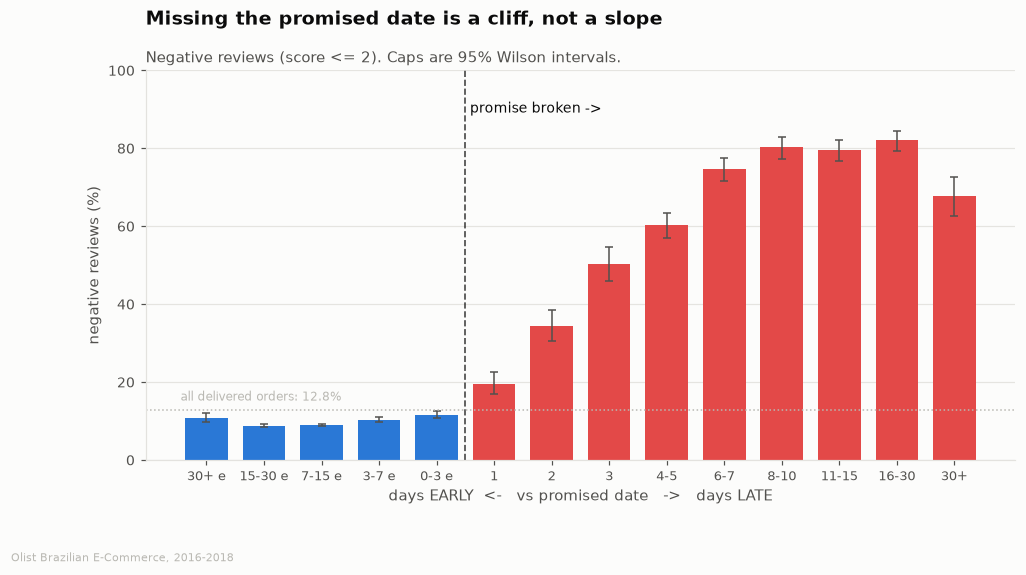

In [8]:
fig, ax = plt.subplots(figsize=(10.2, 4.6))
x = np.arange(len(delay_tab))
colours = [BLUE if s == "on time / early" else BAD for s in delay_tab["side"]]

ax.bar(x, delay_tab["neg_pct"], color=colours, width=0.74)
# Plain caps rather than a shaded band: these are separate buckets, and a band
# would suggest the values join up in between, which they do not.
ax.errorbar(x, delay_tab["neg_pct"],
            yerr=[delay_tab["neg_pct"] - delay_tab["ci_lo"],
                  delay_tab["ci_hi"] - delay_tab["neg_pct"]],
            fmt="none", ecolor=INK_SOFT, elinewidth=1.0, capsize=2.5)

ax.axvline(N_EARLY - 0.5, color=INK, linewidth=1.1, linestyle="--", alpha=0.75)
ax.text(N_EARLY - 0.42, 92, "promise broken ->", fontsize=9, color=INK, va="top")
ax.axhline(baseline, color=MUTED, linewidth=1.0, linestyle=":")
ax.text(-0.45, baseline + 2.5, f"all delivered orders: {baseline:.1f}%",
        fontsize=8, color=MUTED, ha="left")

ax.set_xticks(x)
ax.set_xticklabels(delay_tab["delay_bucket"], fontsize=8.2)
ax.set_ylim(0, 100)
finish(ax, "Missing the promised date is a cliff, not a slope",
       "Negative reviews (score <= 2). Caps are 95% Wilson intervals.",
       "days EARLY  <-   vs promised date   ->   days LATE",
       "negative reviews (%)")
save_fig(fig, "q1_fig01_promise_cliff.png")

In [9]:
early = delay_tab.iloc[:N_EARLY]
print(f"early side spans {early['neg_pct'].min():.1f}% to {early['neg_pct'].max():.1f}% "
      f"across 60+ days of being early")
print(f"one day late already reads {delay_tab.loc[N_EARLY, 'neg_pct']:.1f}%")
print(f"three days late reads {delay_tab.loc[N_EARLY + 2, 'neg_pct']:.1f}%")

early side spans 8.9% to 11.6% across 60+ days of being early
one day late already reads 19.6%
three days late reads 50.4%


### The orders this question cannot see

Q1 can only look at orders that arrived. The ones it leaves out are not a random
leftover.

In [10]:
reviewed = master[master["review_score"].notna()].copy()
excluded = reviewed[~reviewed["order_id"].isin(d["order_id"])]

MIN_PLOT_N = 30   # a rate on 2 orders is not a rate
rows = []
for status, grp in excluded.groupby("order_status"):
    neg = int(grp["is_negative"].astype(bool).sum())
    lo, hi = wilson(neg, len(grp))
    # Nearly all of these never arrived, but a few are marked delivered and just
    # have no delivery date. Calling those "never arrived" would be untrue.
    why = "no delivery date" if status == "delivered" else "never arrived"
    rows.append({"group": f"{status}, {why}", "n": len(grp), "n_negative": neg,
                 "neg_pct": 100 * neg / len(grp), "ci_lo": lo, "ci_hi": hi,
                 "in_analysis": False, "plotted": len(grp) >= MIN_PLOT_N})

for name, grp in [("delivered, late", late), ("delivered, on time", on_time)]:
    neg = int(grp["is_negative"].sum())
    lo, hi = wilson(neg, len(grp))
    rows.append({"group": name, "n": len(grp), "n_negative": neg,
                 "neg_pct": 100 * neg / len(grp), "ci_lo": lo, "ci_hi": hi,
                 "in_analysis": True, "plotted": True})

# Every group goes in the table, including the tiny ones, so a total taken from
# this file later does not quietly lose rows.
excl_full = pd.DataFrame(rows).sort_values("neg_pct").reset_index(drop=True)
save_table(excl_full, "q1_excluded_orders.csv")
excl_full.round(2)

,group,n,n_negative,neg_pct,ci_lo,ci_hi,in_analysis,plotted
0,"delivered, on time",89443,8248,9.22,9.03,9.41,True,True
1,"delivered, no delivery date",8,1,12.50,2.24,47.09,False,False
2,"approved, never arrived",2,1,50.00,9.45,90.55,False,False
3,"delivered, late",6381,3976,62.31,61.11,63.49,True,True
4,"created, never arrived",3,2,66.67,20.77,93.85,False,False
5,"shipped, never arrived",1032,715,69.28,66.40,72.02,False,True
6,"canceled, never arrived",605,464,76.69,73.16,79.89,False,True
7,"invoiced, never arrived",309,253,81.88,77.20,85.77,False,True
8,"unavailable, never arrived",595,504,84.71,81.59,87.37,False,True
9,"processing, never arrived",295,273,92.54,88.97,95.02,False,True


### Figure 2

Sideways bars because the labels are long sentences, and sorted worst first,
otherwise the reader has to do the sorting.

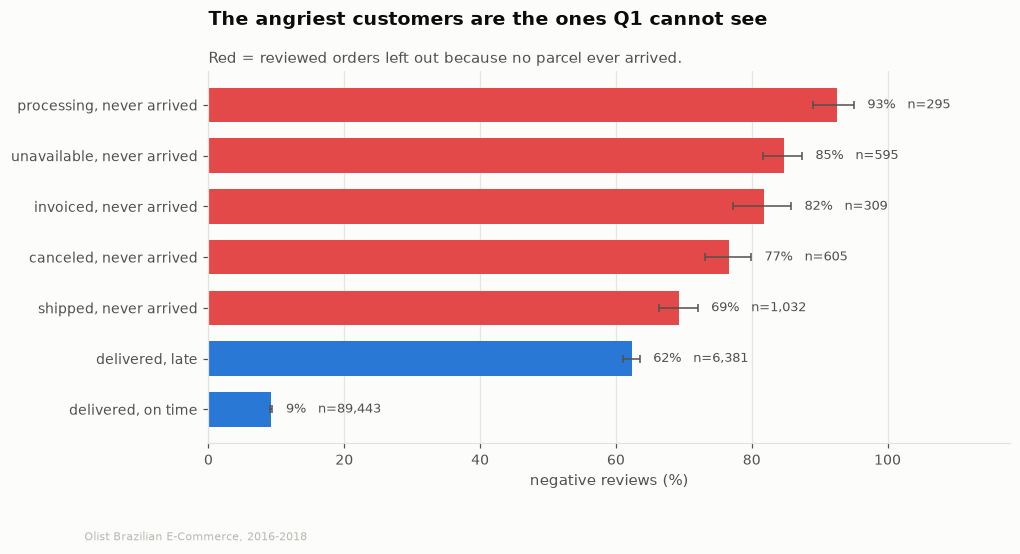

In [11]:
tab = excl_full[excl_full["plotted"]].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9.4, 4.4))
y = np.arange(len(tab))
ax.barh(y, tab["neg_pct"], color=[BLUE if v else BAD for v in tab["in_analysis"]],
        height=0.68)
ax.errorbar(tab["neg_pct"], y,
            xerr=[tab["neg_pct"] - tab["ci_lo"], tab["ci_hi"] - tab["neg_pct"]],
            fmt="none", ecolor=INK_SOFT, elinewidth=1.0, capsize=2.5)

# Past the interval, not the bar: at n=295 the cap is 3 points wide and a label
# placed off the bar value lands on top of it.
for i, row in tab.iterrows():
    ax.text(row["ci_hi"] + 2.0, i, f"{row['neg_pct']:.0f}%   n={row['n']:,}",
            va="center", fontsize=8.5, color=INK_SOFT)

ax.set_yticks(y)
ax.set_yticklabels(tab["group"], fontsize=9)
ax.set_xlim(0, 118)
ax.set_xticks([0, 20, 40, 60, 80, 100])
finish(ax, "The angriest customers are the ones Q1 cannot see",
       "Red = reviewed orders left out because no parcel ever arrived.",
       "negative reviews (%)", grid_axis="x")
save_fig(fig, "q1_fig02_never_arrived.png")

In [12]:
n_exc = len(reviewed) - len(d)
neg_exc = int(reviewed["is_negative"].astype(bool).sum() - d["is_negative"].sum())
print(f"left out : {n_exc:,} reviewed orders, {neg_exc:,} of them negative "
      f"({100 * neg_exc / n_exc:.1f}%)")
print(f"they are {100 * n_exc / len(reviewed):.1f}% of reviewed orders but carry "
      f"{100 * neg_exc / reviewed['is_negative'].astype(bool).sum():.1f}% "
      "of all bad reviews")

left out : 2,849 reviewed orders, 2,213 of them negative (77.7%)
they are 2.9% of reviewed orders but carry 15.3% of all bad reviews


### One check before I answer

Late orders travel further than on-time ones, so someone could argue the gap is
really about distance. I split the orders into four distance groups and measured
again inside each. It stays about 6x everywhere, so distance is not the
explanation.

No chart for this one. Distance and routes are Anushka's question, and neither of
mine asks about geography, so a chart here would duplicate her work. The table
goes to `outputs/q1_distance_control.csv` in case the question comes up.

`geo_distance` is a straight-line distance in degrees, not km, so it can only
rank orders and never quote a distance. I checked it against real great-circle
distance: 98% of orders land in the same group and the ratios do not move.

In [13]:
dist_src = d.dropna(subset=["geo_distance"]).copy()
dist_src["distance_q"] = pd.qcut(
    dist_src["geo_distance"], 4,
    labels=["nearest 25%", "2nd", "3rd", "furthest 25%"])
dist_src["arrival"] = np.where(dist_src["delay_days"] > 0, "late", "on time")

dist = rate_table(dist_src, ["distance_q", "arrival"])
save_table(dist, "q1_distance_control.csv")

piv = dist.pivot(index="distance_q", columns="arrival", values="neg_pct")
(piv["late"] / piv["on time"]).round(2).rename("late / on-time")

distance_q
nearest 25%     6.20
2nd             6.71
3rd             6.93
furthest 25%    6.60
Name: late / on-time, dtype: float64

### Answer to Q1

Delay does not slowly make people unhappy. It breaks at one point, the promised
date. On-time orders are 9.2% negative and late ones are 62.3%, which is 6.8x
worse. Late deliveries are only 6.7% of orders but cause 32.5% of all bad
reviews.

To be fair about it, this only covers orders that arrived. The worst case, an
order that never comes, is left out before the question starts.

# Question 2: Is it being slow, or breaking the promise?

The obvious test is a 2x2, fast or slow against on time or late. I build it below
but it does not work: late orders are nearly always slow as well, so the box that
would separate the two is nearly empty. Instead I measure the same thing twice on
one scale.

In [14]:
SPEED_EDGES = [0, 7, 14, 21, 30, 45, 999]
SPEED_LABELS = ["<=7d", "8-14d", "15-21d", "22-30d", "31-45d", "45d+"]
LATE_EDGES = [0, 2, 5, 10, 20, 40, 999]
LATE_LABELS = ["1-2d", "3-5d", "6-10d", "11-20d", "21-40d", "40d+"]
MIN_N = 100   # below this a point is drawn hollow

ot = on_time.copy()
ot["bucket"] = pd.cut(ot["delivery_days"], SPEED_EDGES, labels=SPEED_LABELS)
speed = rate_table(ot, "bucket")

lt = late.copy()
lt["bucket"] = pd.cut(lt["delay_days"], LATE_EDGES, labels=LATE_LABELS)
lateness = rate_table(lt, "bucket")

save_table(speed, "q2_speed_on_time.csv")
save_table(lateness, "q2_lateness.csv")

print("Promise KEPT: cost of a longer wait")
display(speed[["bucket", "n", "neg_pct", "ci_lo", "ci_hi"]].round(2))
print("Promise BROKEN: cost of being later")
display(lateness[["bucket", "n", "neg_pct", "ci_lo", "ci_hi"]].round(2))

Promise KEPT: cost of a longer wait


,bucket,n,neg_pct,ci_lo,ci_hi
0,<=7d,25875,7.42,7.11,7.75
1,8-14d,39684,8.72,8.45,9.01
2,15-21d,17056,10.62,10.16,11.09
3,22-30d,5873,14.42,13.55,15.34
4,31-45d,910,21.21,18.68,23.98
5,45d+,45,33.33,21.36,47.93


Promise BROKEN: cost of being later


,bucket,n,neg_pct,ci_lo,ci_hi
0,1-2d,1356,25.44,23.20,27.83
1,3-5d,1366,56.66,54.02,59.27
2,6-10d,1634,77.29,75.20,79.26
3,11-20d,1261,80.02,77.72,82.13
4,21-40d,579,82.73,79.44,85.59
5,40d+,185,57.30,50.09,64.21


### Figure 3

Lines, because within each panel the x axis is a length of time. Both panels
share one y scale, which is the whole reason the chart works: with separate
scales each side fills its own box and a 14-point rise looks like a 57-point
one.

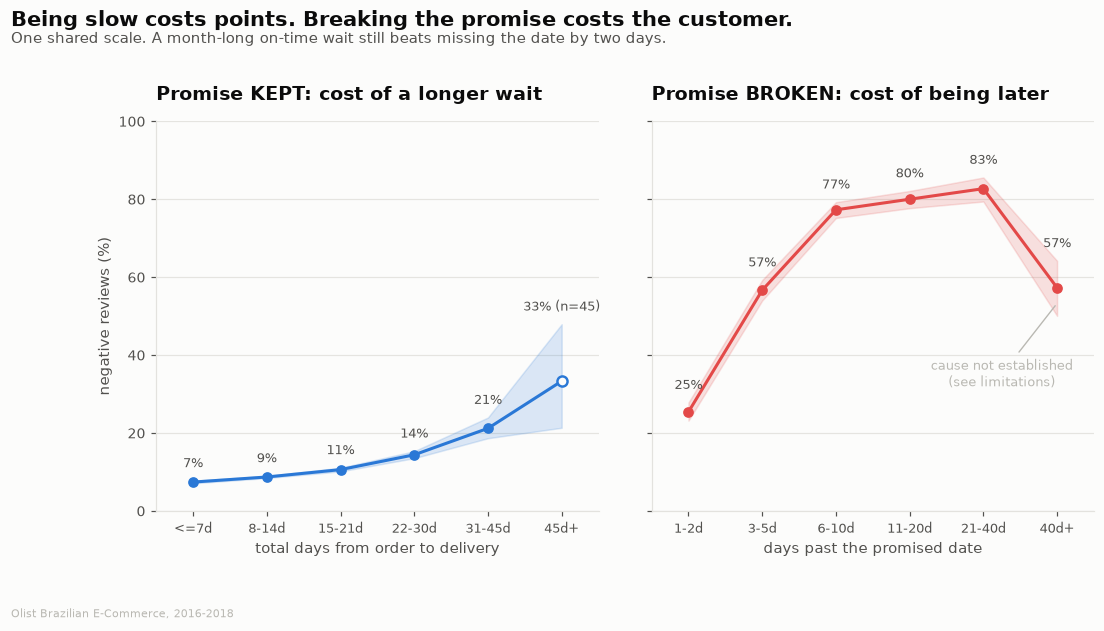

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.6), sharey=True)

panels = [
    (axes[0], speed, BLUE, "Promise KEPT: cost of a longer wait",
     "total days from order to delivery"),
    (axes[1], lateness, BAD, "Promise BROKEN: cost of being later",
     "days past the promised date"),
]

for ax, tb, colour, title, xlab in panels:
    x = np.arange(len(tb))
    solid = tb["n"] >= MIN_N
    ax.plot(x, tb["neg_pct"], color=colour, marker="o", zorder=3)
    ax.fill_between(x, tb["ci_lo"], tb["ci_hi"], color=colour, alpha=0.16, zorder=1)
    # Hollow marker where the bucket is thin, so a shaky point cannot pass for a
    # solid one at a glance.
    ax.scatter(x[~solid], tb.loc[~solid, "neg_pct"], facecolors=SURFACE,
               edgecolors=colour, zorder=4, s=44, linewidths=1.6)
    for xi, row in zip(x, tb.itertuples()):
        note = f"{row.neg_pct:.0f}%" + ("" if row.n >= MIN_N else f" (n={row.n})")
        ax.text(xi, row.ci_hi + 3.5, note, ha="center", fontsize=8.2, color=INK_SOFT)
    ax.set_xticks(x)
    ax.set_xticklabels(tb["bucket"], fontsize=8.6)
    ax.set_xlim(-0.5, len(tb) - 0.5)
    ax.set_title(title, color=INK, pad=14)
    ax.set_xlabel(xlab)
    ax.grid(axis="y", linewidth=0.8, alpha=0.9)
    ax.set_axisbelow(True)

axes[0].set_ylim(0, 100)
axes[0].set_ylabel("negative reviews (%)")

# The last late bucket turns back down. It is not noise, its interval clears the
# plateau, but I could not work out why, and an unexplained dip on a chart reads
# as a finding. Labelled so it does not.
axes[1].annotate("cause not established\n(see limitations)",
                 xy=(len(lateness) - 1, lateness["neg_pct"].iloc[-1] - 4),
                 xytext=(len(lateness) - 1.75, 32),
                 fontsize=8.2, color=MUTED, ha="center",
                 arrowprops=dict(arrowstyle="-", color=MUTED, linewidth=0.9))

fig.suptitle("Being slow costs points. Breaking the promise costs the customer.",
             x=0.005, ha="left", fontsize=13.5, fontweight="bold", y=1.10)
fig.text(0.005, 1.035, "One shared scale. A month-long on-time wait still beats "
                       "missing the date by two days.",
         fontsize=9.5, color=INK_SOFT, ha="left")
fig.text(0.005, -0.10, SOURCE, fontsize=7.5, color=MUTED, ha="left")
fig.subplots_adjust(wspace=0.12)
save_fig(fig, "q2_fig01_two_slopes.png")

In [16]:
solid_speed = speed[speed["n"] >= MIN_N]
solid_late = lateness[lateness["n"] >= MIN_N]
speed_span = solid_speed["neg_pct"].max() - solid_speed["neg_pct"].min()
late_span = solid_late["neg_pct"].max() - solid_late["neg_pct"].min()

print(f"keeping the promise : {speed_span:5.1f} pp span "
      f"({solid_speed['neg_pct'].min():.1f}% to {solid_speed['neg_pct'].max():.1f}%)")
print(f"breaking it         : {late_span:5.1f} pp span "
      f"({solid_late['neg_pct'].min():.1f}% to {solid_late['neg_pct'].max():.1f}%)")
print()
print(f"the broken-promise axis spans {late_span / speed_span:.1f}x as much")

keeping the promise :  13.8 pp span (7.4% to 21.2%)
breaking it         :  57.3 pp span (25.4% to 82.7%)

the broken-promise axis spans 4.2x as much


### Why the gap is so wide

I found this while trying to work out why the last late bucket looked odd.

In [17]:
tm = d.copy()
# This needs format="mixed". master_orders.csv stores review_creation_date in two
# formats, and pandas infers one and turns the rest into NaT with no warning,
# which quietly destroys 84% of the column.
for c in ["review_creation_date", "order_delivered_customer_date",
          "order_estimated_delivery_date"]:
    before = tm[c].isna().sum()
    tm[c] = pd.to_datetime(tm[c], errors="coerce", format="mixed")
    assert tm[c].isna().sum() == before, f"parsing {c} created new nulls"

tm["vs_delivery"] = (tm["review_creation_date"]
                     - tm["order_delivered_customer_date"].dt.normalize()).dt.days
tm["regime"] = np.where(tm["delay_days"] > 0, "promise broken", "promise kept")

timing = pd.DataFrame([{
    "regime": regime,
    "n": len(grp),
    "median_days_after_actual_delivery": grp["vs_delivery"].median(),
    "pct_reviewed_before_parcel_arrived": 100 * (grp["vs_delivery"] < 0).mean(),
} for regime, grp in tm.groupby("regime")])
save_table(timing, "q2_review_timing.csv")
timing.round(1)

,regime,n,median_days_after_actual_delivery,pct_reviewed_before_parcel_arrived
0,promise broken,6381,-4.0,74.5
1,promise kept,89443,1.0,0.3


### Figure 4

The answer here is a share, so I drew a share. My first attempt was a histogram
and it did not work: 93% of on-time reviews land in a single one-day bin, so that
one spike set the scale and flattened everything else.

Each block is labelled with its own number. My first version put "0.3%" just to
the right of the sliver, which landed it on the blue block and read as if blue
were 0.3%. It is now labelled from outside with a line pointing at it, so no
number sits on a block it does not belong to.

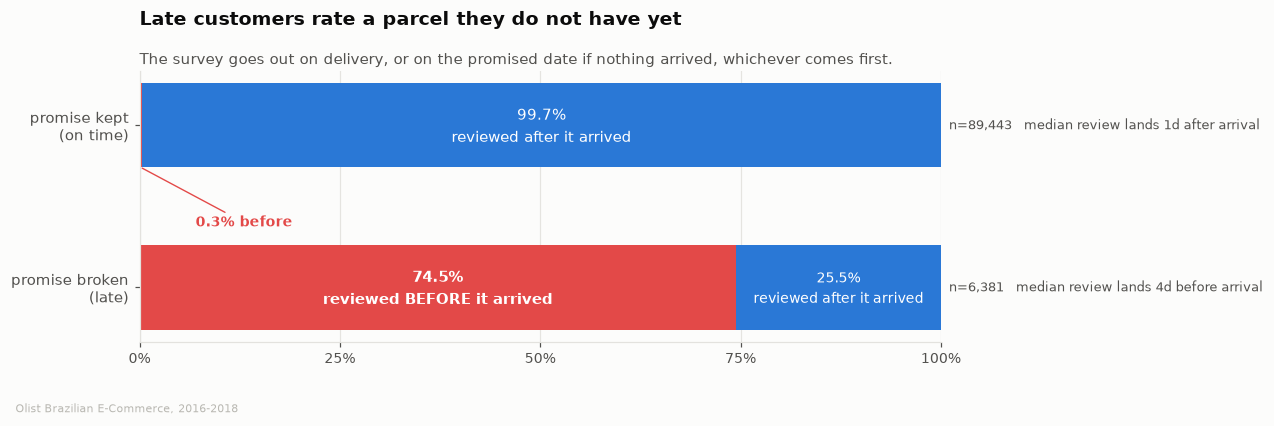

In [18]:
fig, ax = plt.subplots(figsize=(9.4, 3.2))
order = ["promise kept", "promise broken"]
y = np.arange(len(order))
before = [float(timing.loc[timing["regime"] == r,
                           "pct_reviewed_before_parcel_arrived"].iloc[0])
          for r in order]

ax.barh(y, before, color=BAD, height=0.52)
ax.barh(y, [100 - b for b in before], left=before, color=BLUE, height=0.52)

for i, (r, b) in enumerate(zip(order, before)):
    n = int(timing.loc[timing["regime"] == r, "n"].iloc[0])
    med = float(timing.loc[timing["regime"] == r,
                           "median_days_after_actual_delivery"].iloc[0])
    if b > 20:
        ax.text(b / 2, i, f"{b:.1f}%\nreviewed BEFORE it arrived", ha="center",
                va="center", color="white", fontsize=10, fontweight="bold",
                linespacing=1.45)
    else:
        # Too thin to hold text, so point at it from outside. Bars are 0.52 tall,
        # so +0.26 is exactly the bottom edge of the sliver.
        ax.annotate(f"{b:.1f}% before", xy=(b / 2, i + 0.26), xytext=(7, i + 0.60),
                    fontsize=9, fontweight="bold", color=BAD, ha="left",
                    va="center",
                    arrowprops=dict(arrowstyle="-", color=BAD, linewidth=0.9,
                                    shrinkA=0, shrinkB=1))
    ax.text(b + (100 - b) / 2, i, f"{100 - b:.1f}%\nreviewed after it arrived",
            ha="center", va="center", color="white",
            fontsize=10 if b <= 20 else 9, linespacing=1.45)
    ax.text(101, i, f"n={n:,}   median review lands {abs(med):.0f}d "
                    f"{'before' if med < 0 else 'after'} arrival",
            ha="left", va="center", fontsize=8.3, color=INK_SOFT)

ax.set_yticks(y)
ax.set_yticklabels(["promise kept\n(on time)", "promise broken\n(late)"], fontsize=9.5)
ax.set_xlim(0, 100)
ax.set_xticks([0, 25, 50, 75, 100])
ax.set_xticklabels(["0%", "25%", "50%", "75%", "100%"])
ax.invert_yaxis()
finish(ax, "Late customers rate a parcel they do not have yet",
       "The survey goes out on delivery, or on the promised date if nothing "
       "arrived, whichever comes first.", grid_axis="x")
save_fig(fig, "q2_fig02_review_timing.png")

The review survey is sent when the order is delivered, or on the promised date
if it still has not arrived, whichever happens first. Only 0.3% of on-time
customers get it before their order arrives. For late customers it is 74.5%.

So three out of four late reviews are not about a late delivery at all. They are
about an order that had not shown up yet, asked right when the promise broke.

### The 2x2, reported but not relied on

In [19]:
tw = d.copy()
cut = tw["delivery_days"].median()
tw["speed"] = np.where(tw["delivery_days"] <= cut, "fast", "slow")
tw["promise"] = np.where(tw["delay_days"] > 0, "broken", "kept")

two = rate_table(tw, ["promise", "speed"])
save_table(two, "q2_two_by_two.csv")

print(f"split at the median delivery time of {cut:.1f} days")
two[["promise", "speed", "n", "neg_pct", "ci_lo", "ci_hi"]].round(2)

split at the median delivery time of 10.2 days


,promise,speed,n,neg_pct,ci_lo,ci_hi
0,broken,fast,187,24.06,18.50,30.67
1,broken,slow,6194,63.46,62.26,64.66
2,kept,fast,47725,7.85,7.61,8.09
3,kept,slow,41718,10.79,10.50,11.10


The broken and fast box holds 187 orders out of 95,824 and its error bar spans
12 points. It points the same way as the two-line result, which is worth saying,
but it is too small to prove anything.

### Answer to Q2

Breaking the promise, clearly. An order that took over a month but arrived on the
promised day (21.2% negative) is still better than one that was 1 to 2 days late
(25.4%). People are not really rating how long they waited, they are rating the
difference between what they were told and what happened.

## Chart choices

A short note on why each chart looks the way it does.

| Figure | Chart | Why |
|---|---|---|
| 1 | bars split at zero | bars start from the same line so lengths are easy to compare, and the dashed line shows the split straight away |
| 2 | sideways bars, sorted | the labels are long sentences, and sorting saves the reader doing it |
| 3 | two line charts, same scale | with separate scales a 14-point rise looks like a 57-point one |
| 4 | stacked bar of shares | the answer is a share. I tried a histogram first and one bar held 93% of the group, so everything else went flat |

Rules I stuck to: only two colours and each means something (blue normal, red
always the bad outcome, and the two stay apart for colour-blind readers where red
and green would not); no second y axis; every rate gets an error bar and thin
buckets are drawn hollow; labels on the bars instead of a legend where there is
room; light grid and no box, so the data is the darkest thing on the page.

## Limitations

- These are patterns, not proof of cause. The distance check is one check, not a
  model.
- Everything here only covers orders that arrived. The ones that never did are
  kept separate and never mixed in.
- Orders more than 40 days late are *less* negative, and the error bars do not
  overlap the ones before them, so it is not just a small-numbers wobble. Those
  orders have impossible transit times, about 124 days on average, which makes me
  think the delivery date was filled in later rather than being real. I could not
  prove that, so the chart says the cause is not established instead of me making
  one up.
- Reviews only come from customers who answer the survey, and Figure 4 shows the
  survey does not go out at the same moment for both groups.

## Conclusions

1. The promised date is what matters, not the wait. Before it everything is flat,
   after it everything falls apart.
2. Delivering early does not buy goodwill. Sixty days of it is worth about two
   points.
3. The cheapest fix is not faster delivery, it is a more honest promised date. The
   estimate is set by the platform, so it is the one thing here you can change
   without touching logistics.
4. The real problem is bigger than these charts show. Orders that never arrive are
   2.9% of reviewed orders and 15.3% of all bad reviews, and no delivery-time
   analysis can see them.